In [116]:
#1 Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [117]:
#2. Generación de datos de ejemplo
# Datos adaptados de: https://totoro.banrep.gov.co/analytics/saw.dll?Go&Action=prompt&path=%2Fshared%2FSeries%20Estad%C3%ADsticas_T%2F1.%20Tasa%20de%20Cambio%20Peso%20Colombiano%2F1.1%20TRM%20-%20Disponible%20desde%20el%2027%20de%20noviembre%20de%201991%2F1.1.16.TCM_Serie%20historica_ultimos_doce%20meses&Options=rdf&lang=es

import csv
import pandas as pd

# Ruta a tu archivo de etiquetas
archivo_csv = "1.1.16.TCM_Serie historica_ultimos_doce meses.csv"

# Leer el archivo CSV en un DataFrame especificando el delimitador
df = pd.read_csv(archivo_csv, delimiter=';', decimal=',')

# Asegurar que la columna 'Fecha' esté en formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
df = df.drop(columns=[';'])
# Eliminar espacios en los nombres de las columnas si es necesario
df.columns = df.columns.str.strip()
# Reemplazar comas por puntos y convertir a float
# Eliminar los puntos de los miles y reemplazar comas por puntos decimales
df['TRM'] = df['TRM'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)

# Verificar resultados
print(df.head())
print("columnas", df.columns)
print("tipo", df.dtypes)  # Verifica el tipo de datos de la columna 'TRM'


       Fecha      TRM
0 2024-08-14  4038.87
1 2024-08-13  4063.26
2 2024-08-12  4064.51
3 2024-08-11  4064.51
4 2024-08-10  4064.51
columnas Index(['Fecha', 'TRM'], dtype='object')
tipo Fecha    datetime64[ns]
TRM             float64
dtype: object


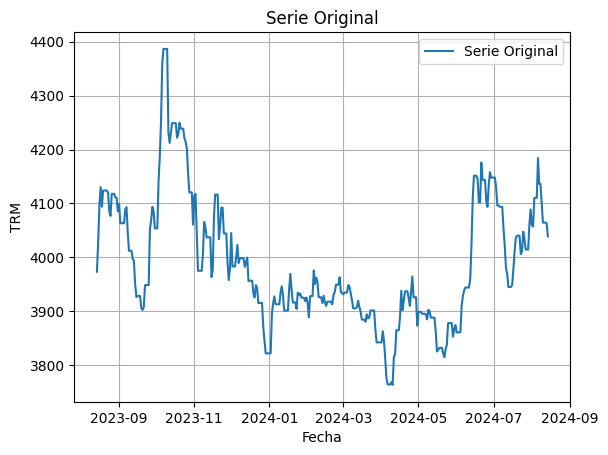

In [118]:
# 3. Gráfica de la serie original
plt.plot(df['Fecha'], df['TRM'], label='Serie Original')
plt.title('Serie Original')
plt.xlabel('Fecha')
plt.ylabel('TRM')
plt.legend()
plt.grid(True)
plt.show()

In [119]:
#4. Descomposición de la serie de tiempo

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Como se tiene el DataFrame df con las columnas 'Fecha' y 'TRM'

# Configurar la columna 'Fecha' como índice
df.set_index('Fecha', inplace=True)

# Asegurarse de que el índice sea un DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("El índice del DataFrame debe ser un DatetimeIndex.")

#Nota: Después de establecer la columna 'Fecha' como índice, no estará disponible
#como una columna en el DataFrame df. Por tanto, debe volverse a ejecutar todo el código
#porque, cuando se intenta acceder a df['Fecha'],
#se produce un KeyError porque la columna 'Fecha' no existe en el DataFrame.

# Establecer la frecuencia del índice si es necesario
df = df.asfreq('D')  # 'D' para datos diarios, ajusta si es diferente (por ejemplo, 'W' para semanal, 'M' para mensual)

# Seleccionar la serie de tiempo
ts = df['TRM']

# Descomposición de la serie de tiempo
#Se especificó un period=180, porque la descomposición espera al menos 360 observaciones (1 año)
#lo cual corresponde al número de datos del dataframe.
descomposition = seasonal_decompose(ts, model='additive', period=180)  # Ajusta el período según tu estacionalidad



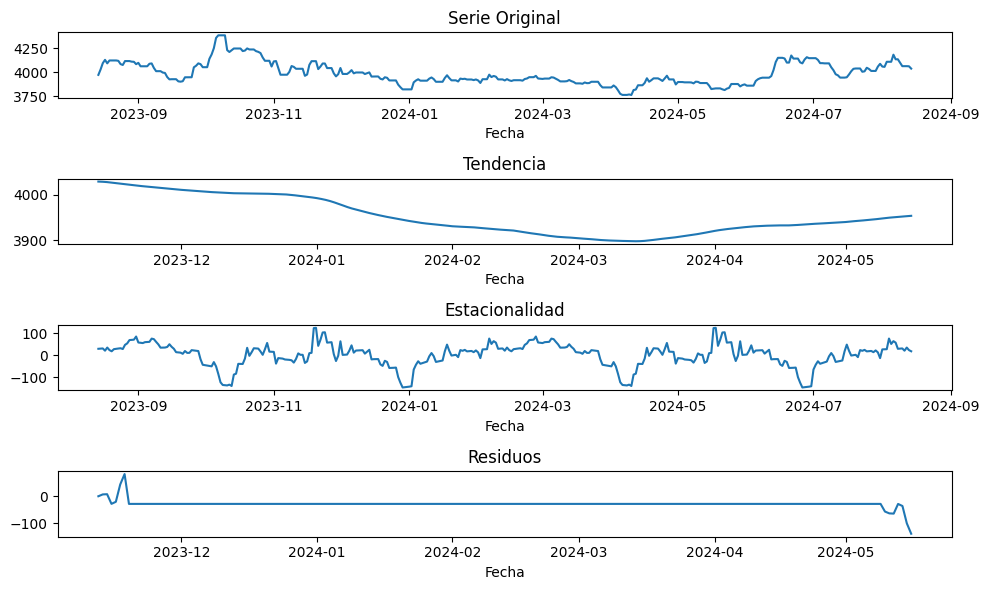

In [120]:
#5. Gráfica de la descomposición

#Gráfica de la serie original
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(ts, label='Serie Original')
plt.title('Serie Original')
plt.xlabel('Fecha')

#Gráfica de la tendencia
plt.subplot(412)
plt.plot(descomposition.trend, label='Tendencia')
plt.title('Tendencia')
plt.xlabel('Fecha')

#Gráfica de la estacionalidad
plt.subplot(413)
plt.plot(descomposition.seasonal, label='Estacionalidad')
plt.title('Estacionalidad')
plt.xlabel('Fecha')

#Gráfica de los residuos
plt.subplot(414)
plt.plot(descomposition.resid, label='Residuos')
plt.title('Residuos')
plt.xlabel('Fecha')

plt.tight_layout()
plt.show()